In [5]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from sklearn.datasets import make_moons, make_swiss_roll
from sklearn.preprocessing import StandardScaler
from torch import Tensor
from torch.distributions import Normal
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
from typing import *
import numpy as np
import pandas as pd

class OptimalFlow(nn.Module):
    def __init__(self, model: nn.Module, sigma_min: int = 0.0001):
        super().__init__()
        self.sigma_min = sigma_min
        self.model = model

    def psi_t(self, x_1, x_0, t):
        """
        x_1 : data
        x_0 : noise
        """
        x_t = t * x_1 + (1 - (1 - self.sigma_min) * t) * x_0
        return x_t

    def loss(self, x_1, t):
        t = t[:, None].expand(x_1.shape)
        x_0 = torch.randn_like(x_1).to(x_1.device) # x_T ~ Gaussian
        noised = self.psi_t(x_1, x_0, t) # x_t
        pred = self.model(noised, t)
        target = x_1 - (1 - self.sigma_min) * x_0
        loss = torch.mean((target - pred)**2)
        return loss

    def forward(self, x_t, t):
        return self.model(x_t, t)

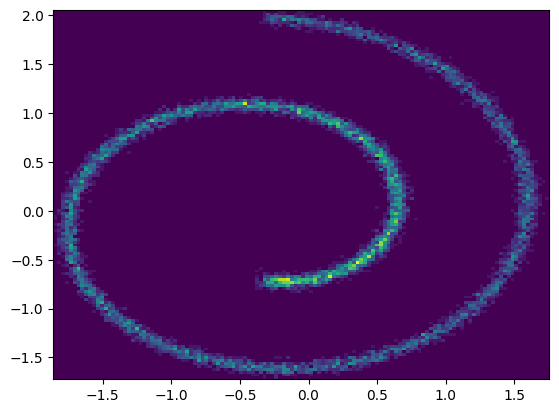

In [6]:
def get_data(dataset: str, n_points: int) -> np.ndarray:
  if dataset == "moons":
    data, _ = make_moons(n_points, noise=0.15)
  elif dataset == "swiss":
    data, _ = make_swiss_roll(n_points, noise=0.25)
    data = data[:, [0, 2]] / 10.0
  return StandardScaler().fit_transform(data)

device = 'cuda'
n_points = 10_000
DATASET = "swiss"
data = get_data(DATASET, n_points)

%matplotlib inline
plt.hist2d(data[:, 0], data[:, 1], bins=128)
plt.show()


batch_size = 2048
dataset = torch.from_numpy(data).float()
dataset = dataset.to(device)
dataset = TensorDataset(dataset) 
dataloader = DataLoader(dataset, batch_size=batch_size)

In [7]:
#@title ⏳ Summary: please run this cell which contains the ```Net``` class.
class Net(nn.Module):
  def __init__(self, in_dim: int, out_dim: int, h_dims: List[int], n_frequencies:int) -> None:
    super().__init__()

    ins = [in_dim + 2 * n_frequencies] + h_dims
    outs = h_dims + [out_dim]
    self.n_frequencies = n_frequencies

    self.layers = nn.ModuleList([
        nn.Sequential(nn.Linear(in_d, out_d), nn.LeakyReLU()) for in_d, out_d in zip(ins, outs)
    ])
    self.top = nn.Sequential(nn.Linear(out_dim, out_dim))
  
  def time_encoder(self, t: torch.Tensor) -> torch.Tensor:
    freq = 2 * torch.arange(self.n_frequencies, device=t.device) * torch.pi
    t = freq * t[..., None]
    return torch.cat((t.cos(), t.sin()), dim=-1)
    
  def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
    t = self.time_encoder(t[:, 0])
    x = torch.cat((x, t), dim=-1)
    
    for l in self.layers:
        x = l(x)
    return self.top(x)

net = Net(2, 2, [512]*5, 10).to(device)
ot = OptimalFlow(net).to(device)

In [9]:
losses = [] 
# configure optimizer
optimizer = torch.optim.Adam(ot.parameters(), lr=1e-3)
n_epochs = 5009
    
for epoch in tqdm(range(n_epochs), ncols=88):
    for batch in dataloader:
        x_1 = batch[0].to(device)
        t = torch.rand((x_1.shape[0],)).to(device)
        # compute loss 
        loss = ot.loss(x_1, t)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses += [loss.detach()]

        if epoch%500 == 0:
            print(epoch, loss)

  0%|▏                                                 | 3/1009 [00:00<01:55,  8.73it/s]

0 tensor(2.2245, device='cuda:0', grad_fn=<MeanBackward0>)
0 tensor(2.1882, device='cuda:0', grad_fn=<MeanBackward0>)
0 tensor(2.1368, device='cuda:0', grad_fn=<MeanBackward0>)
0 tensor(2.1531, device='cuda:0', grad_fn=<MeanBackward0>)
0 tensor(2.0646, device='cuda:0', grad_fn=<MeanBackward0>)


 50%|███████████████████████▉                        | 502/1009 [00:27<00:27, 18.41it/s]

500 tensor(1.4196, device='cuda:0', grad_fn=<MeanBackward0>)
500 tensor(1.4351, device='cuda:0', grad_fn=<MeanBackward0>)
500 tensor(1.3979, device='cuda:0', grad_fn=<MeanBackward0>)
500 tensor(1.4496, device='cuda:0', grad_fn=<MeanBackward0>)
500 tensor(1.4471, device='cuda:0', grad_fn=<MeanBackward0>)


100%|██████████████████████████████████████████████▊| 1004/1009 [00:54<00:00, 19.46it/s]

1000 tensor(1.4336, device='cuda:0', grad_fn=<MeanBackward0>)
1000 tensor(1.3824, device='cuda:0', grad_fn=<MeanBackward0>)
1000 tensor(1.4472, device='cuda:0', grad_fn=<MeanBackward0>)
1000 tensor(1.4389, device='cuda:0', grad_fn=<MeanBackward0>)
1000 tensor(1.3705, device='cuda:0', grad_fn=<MeanBackward0>)


100%|███████████████████████████████████████████████| 1009/1009 [00:55<00:00, 18.28it/s]


In [33]:
from zuko.utils import odeint

x_t = torch.randn((size, 2))
output = odeint(ot, x_t, 0., 1., ot.parameters())

size = 3200
timesteps = torch.linspace(0, 1, 64)

with torch.no_grad():
    for t in timesteps:
        x_t = ot(x_t.to(device), t.repeat(size).unsqueeze(-1).to(device))
    print(x_t.shape)

RuntimeError: zero-dimensional tensor (at position 0) cannot be concatenated

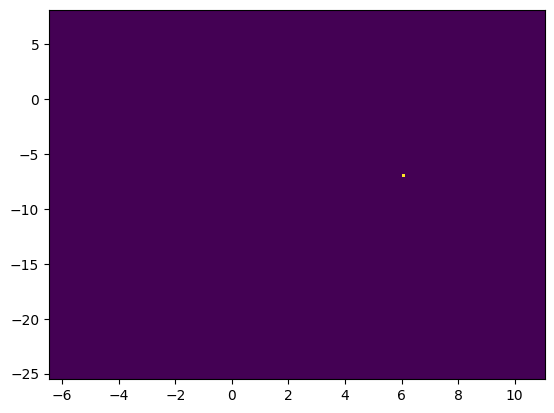

In [30]:
x_t = x_t.cpu().detach().numpy()

%matplotlib inline
plt.hist2d(x_t[:, 0], x_t[:, 1], bins=128)
plt.show()

In [20]:
data.shape

(10000, 2)

In [15]:
import math
import torch
device='cuda'
# TIMEStep Sampling for diffusion process
image_token_size = 8*8  # h * w
batch_size = 256
z = torch.randn(batch_size, device=device, dtype=torch.float32)
alpha = 2 * math.sqrt(image_token_size / (8 * 8))

# Mix uniform and lognormal sampling for better coverage of timesteps
do_uniform = torch.rand(batch_size, device=device, dtype=torch.float32) < 0.1
uniform = torch.rand(batch_size, device=device, dtype=torch.float32)
t = torch.nn.Sigmoid()(z)
lognormal = t * alpha / (1 + (alpha - 1) * t)

# Final timesteps
t = torch.where(~do_uniform, lognormal, uniform).to(torch.float32)

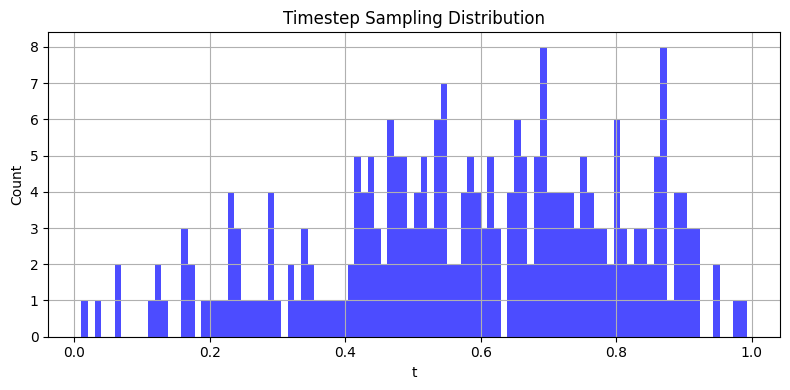

In [16]:
# 3. 히스토그램 시각화
plt.figure(figsize=(8, 4))
plt.hist(t.cpu().numpy(), bins=100, color='blue', alpha=0.7)
plt.title("Timestep Sampling Distribution")
plt.xlabel("t")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
target_vf = torch.ones((4, 16, 64))
predicted_vf = torch.zeros((4, 16, 64))

loss = torch.nn.functional.mse_loss(target_vf, predicted_vf, reduction='none').mean(dim=(1,2))
loss.shape

torch.Size([4])

In [27]:
loss.mean()

tensor(1.)

In [28]:
import os
import shutil
from tqdm import tqdm

# 원본 이미지 경로 리스트
valid_paths = [f'/workspace/personal_tests/img_align_celeba/{i:06d}.jpg' for i in range(170000, 172560)]

# 복사 대상 디렉토리
destination_dir = "/workspace/personal_tests/valid_images"
os.makedirs(destination_dir, exist_ok=True)

# 이미지 복사
for src_path in tqdm(valid_paths):
    filename = os.path.basename(src_path)
    dst_path = os.path.join(destination_dir, filename)
    
    if os.path.exists(src_path):
        shutil.copyfile(src_path, dst_path)
    else:
        print(f"파일 없음: {src_path}")

100%|██████████| 2560/2560 [00:24<00:00, 102.80it/s]


In [ ]:
from cleanfid import fid

fid_score = fid.compute_fid(
    "/workspace/personal_tests/FM/logs_fm_0528_celeba_fid/validsets_0",
    "/workspace/personal_tests/valid_images/", 
)

compute FID between two folders
Found 2550 images in the folder /workspace/personal_tests/FM/logs_fm_0528_celeba_fid/validsets_0


FID validsets_0 :   1%|▏         | 1/80 [00:01<01:49,  1.39s/it]

In [32]:
fid_score

266.6547105077142

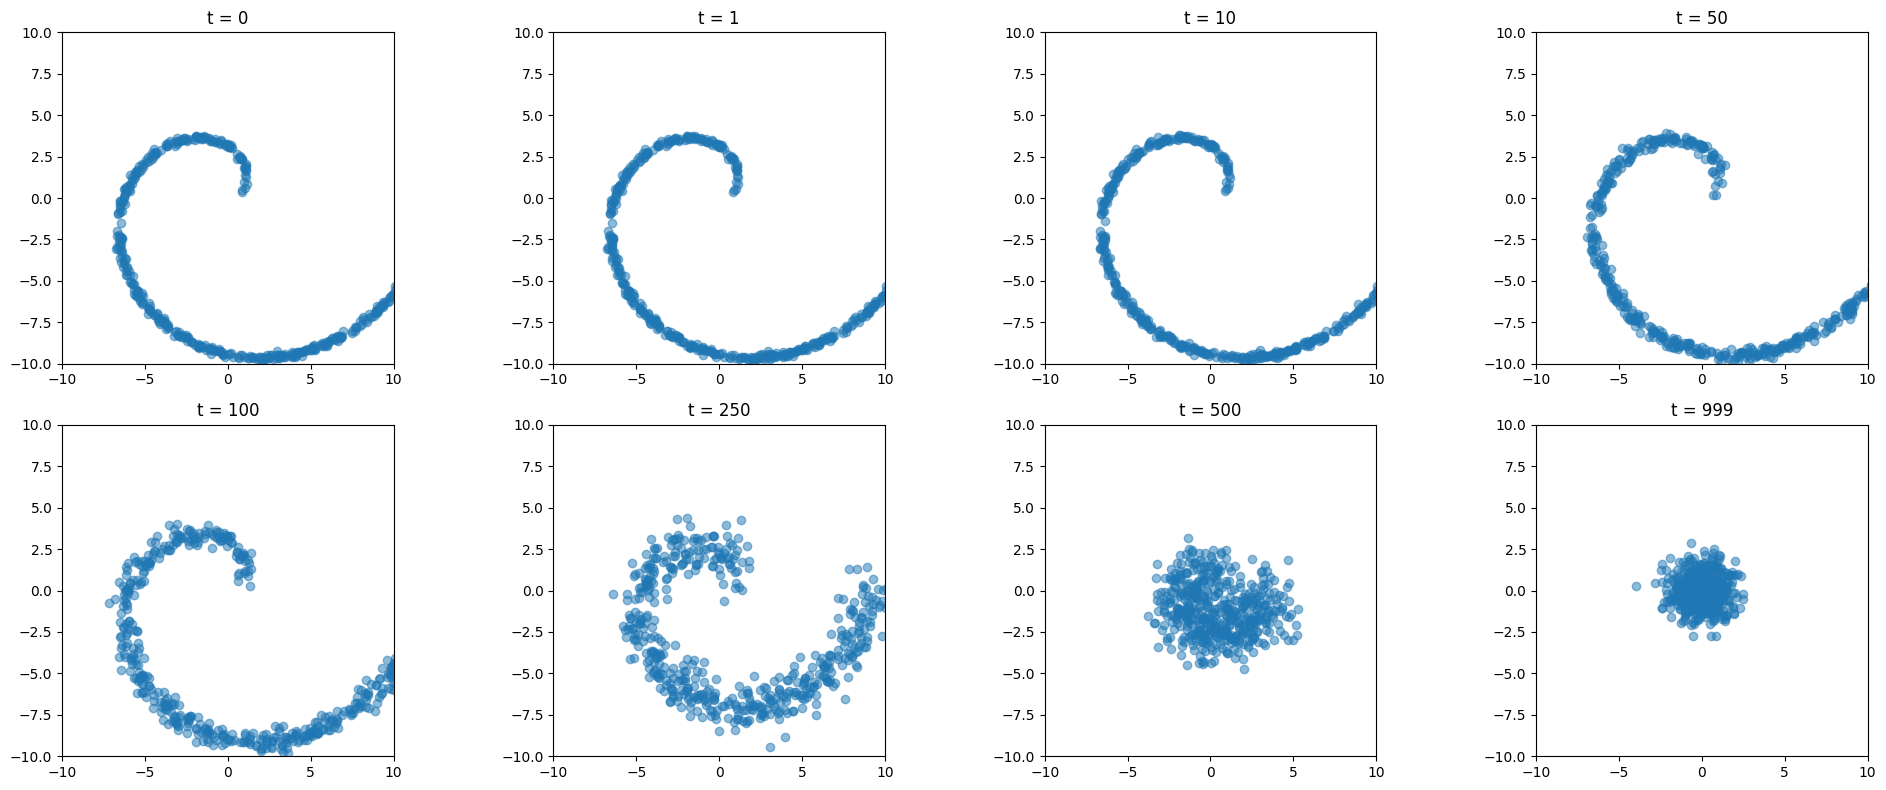

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# DDPM parameters
T = 1000  # total diffusion steps
beta_start = 1e-4
beta_end = 0.02
betas = np.linspace(beta_start, beta_end, T)

alphas = 1.0 - betas
alpha_bars = np.cumprod(alphas)  # \bar{\alpha}_t = prod_{s=1}^t (1 - beta_s)

# Simulate 2D data
np.random.seed(42)
num_samples = 500
x0 = np.random.randn(num_samples, 2)  # p0 ~ N(0, I) for simplicity

# Compute x_t at different timesteps
timesteps = [0, 1, 10, 50, 100, 250, 500, 999]
samples_by_t = {}

# Generate 2D spiral data to better visualize how structure is destroyed by noise
def generate_spiral_data(n_points=500, noise=0.1):
    theta = np.sqrt(np.random.rand(n_points)) * 2 * np.pi  # angle
    r = 2 * theta  # radius
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    data = np.stack([x, y], axis=1)
    data += np.random.randn(n_points, 2) * noise
    return data

# Spiral data as x0
x0_spiral = generate_spiral_data()

# Apply DDPM forward noise process
samples_by_t_spiral = {}

for t in timesteps:
    sqrt_alpha_bar_t = np.sqrt(alpha_bars[t])
    sqrt_one_minus_alpha_bar_t = np.sqrt(1 - alpha_bars[t])
    noise = np.random.randn(num_samples, 2)
    x_t = sqrt_alpha_bar_t * x0_spiral + sqrt_one_minus_alpha_bar_t * noise
    samples_by_t_spiral[t] = x_t

# Plotting
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for i, t in enumerate(timesteps):
    axes[i].scatter(samples_by_t_spiral[t][:, 0], samples_by_t_spiral[t][:, 1], alpha=0.5)
    axes[i].set_title(f"t = {t}")
    axes[i].set_xlim(-10, 10)
    axes[i].set_ylim(-10, 10)
    axes[i].set_aspect('equal')

plt.tight_layout()
plt.show()


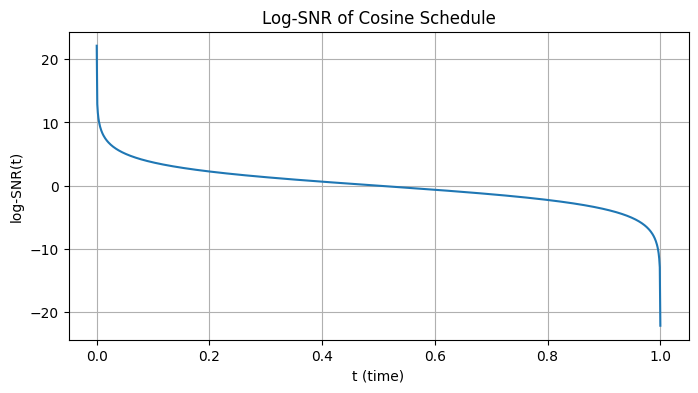

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# t in [0, 1] but avoid exactly 0 or 1 to prevent division by 0
t = np.linspace(1e-5, 1 - 1e-5, 1000)
log_snr_cosine = 2 * np.log(np.cos(np.pi / 2 * t) / np.sin(np.pi / 2 * t))

# Plotting
plt.figure(figsize=(8, 4))
plt.plot(t, log_snr_cosine)
plt.title("Log-SNR of Cosine Schedule")
plt.xlabel("t (time)")
plt.ylabel("log-SNR(t)")
plt.grid(True)
plt.show()
